In [2]:
from src.ism_engine import PlantGenoAnnISMEngine

In [3]:
fasta_file = "Zea_mays.Zm-B73-REFERENCE-NAM-5.0.dna.chromosome.4.fa"
model_path = "PlantGenoAnn-model-plants"
output_path = "./zma_brittle2_intron3_ism_score.npy"
chrom = "4"
start_pos = 61581787
end_pos = 61581807

In [4]:
engine = PlantGenoAnnISMEngine(
    fasta_file=fasta_file, 
    repo_id=model_path, 
    output_path=output_path, 
    batch_size=24,
    seq_len=49152,
    slice_len=32768,
)

In [5]:
engine.process_region(
    chrom=chrom,
    start_pos=start_pos,
    end_pos=end_pos,
    strand="+",
)

Inference [RULE3]: 100%|██████████| 1/1 [00:05<00:00,  5.92s/it]

ISM score has been saved in ./zma_brittle2_intron3_ism_score.npy


In [6]:
import matplotlib.pyplot as plt
from Bio import SeqIO
import logomaker
import pandas as pd
import numpy as np

In [13]:
genome = SeqIO.index(fasta_file, "fasta")
chrom_seq = str(genome[chrom].seq).upper()
sequence_intron3 = chrom_seq[start_pos-1:end_pos]
ism_score_intron3 = np.abs(np.load(output_path))
print(sequence_intron3)

AAGCAATGATGGTACACATAA


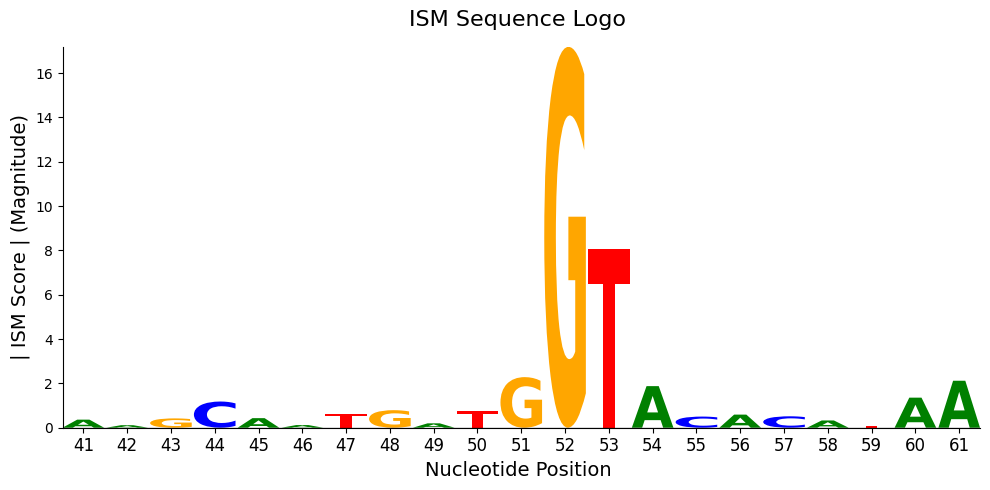

In [15]:
df_data = np.zeros((len(sequence_intron3), 4))
logo_df = pd.DataFrame(df_data, columns=['A', 'C', 'G', 'T'])

for i, base in enumerate(sequence_intron3):
    if base in logo_df.columns:
        logo_df.loc[i, base] = ism_score_intron3[i] 

fig, ax = plt.subplots(figsize=(10, 5))

logo = logomaker.Logo(logo_df,
                      ax=ax,
                      stack_order='big_on_top')

color_scheme = {'A': 'forestgreen', 'C': 'blue', 'G': 'orange', 'T': 'red'}
logo.style_glyphs(color_dict=color_scheme, font_name='sans-serif', fontweight='bold')

ax.set_ylabel('| ISM Score | (Magnitude)', fontsize=14) 
ax.set_xlabel('Nucleotide Position ', fontsize=14)
ax.set_title('ISM Sequence Logo ', fontsize=16, pad=15)

x_ticks_idx = np.arange(0, len(sequence_intron3))
x_tick_labels = [str(41 + i) for i in x_ticks_idx]
ax.set_xticks(x_ticks_idx)
ax.set_xticklabels(x_tick_labels, fontsize=12)
ax.axhline(y=0, color='black', linewidth=1, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()